# Proyecto de Aula — Entrega 4
## Parte 1: Modelos basados en árboles

> [link al video](https://www.youtube.com/watch?v=ZLzwYXcebBg)

**Objetivo:** Desarrollar un árbol de decisión y un modelo de boosting (GradientBoostingClassifier) para predecir `procedencia_tutela`, aplicar sintonización de hiperparámetros mediante validación cruzada y comparar los tres modelos del proyecto.

> **Nota metodológica:** Para garantizar comparabilidad, los tres modelos usan las **mismas particiones** (`random_state=42`, `test_size=0.2`, estratificado) y la misma técnica de sintonización (`GridSearchCV` con `StratifiedKFold(n_splits=5, random_state=42)`).


## 1. Importaciones y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay
)

SEED = 42
np.random.seed(SEED)
print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


## 2. Carga y revisión del conjunto de datos

In [2]:
df = pd.read_csv("data.csv")
print("Dimensiones:", df.shape)
df.head()


Dimensiones: (352, 29)


,id_sentencia,año,tema_principal,tipo_accionante,sujeto_especial_proteccion,edad_aproximada,representacion,tipo_entidad,sector_entidad,derecho_salud,...,legitimacion_activa,legitimacion_pasiva,urgencia,afecta_minimo vital,afecta_salud,caso_involucra_servicio_publico,decision_corte,procedencia_tutela,dias_desde_hecho,hay_inmediatez
0,t-003,2022,seguridad_social,persona_natural,0.0,55.0,agente_oficioso,economia_mixta,salud,1,...,0,1,0,0,0,1,improcedente,0.0,7.0,1.0
1,t-256,2019,seguridad_social,persona_natural,1.0,69.0,directo,privada,otro,0,...,1,1,1,1,0,1,concede,1.0,74.0,1.0
2,t-056,2013,seguridad_social,persona_natural,0.0,NaN,apoderado,publica,otro,0,...,1,1,0,0,0,0,niega,1.0,NaN,0.0
3,t-852,2012,seguridad_social,persona_natural,1.0,65.0,apoderado,publica,otro,0,...,1,1,0,0,0,1,improcedente,0.0,NaN,0.0
4,t-608,2016,seguridad_social,persona_natural,1.0,50.0,apoderado,publica,pensiones,1,...,1,1,1,1,1,1,concede,1.0,30.0,1.0


In [3]:
info = pd.DataFrame({
    "dtype": df.dtypes,
    "nulos": df.isnull().sum(),
    "% nulos": (df.isnull().mean() * 100).round(2)
})
display(info[info["nulos"] > 0])


,dtype,nulos,% nulos
sujeto_especial_proteccion,float64,1,0.28
edad_aproximada,float64,168,47.73
tipo_entidad,str,9,2.56
sector_entidad,str,3,0.85
procedencia_tutela,float64,1,0.28
dias_desde_hecho,float64,132,37.50
hay_inmediatez,float64,1,0.28


In [4]:
print("Distribución del target:")
display(df["procedencia_tutela"].value_counts(dropna=False))
print(f"Balance: {df['procedencia_tutela'].value_counts(normalize=True).round(3).to_dict()}")


Distribución del target:


procedencia_tutela
1.0    252
0.0     99
NaN      1
Name: count, dtype: int64

Balance: {1.0: 0.718, 0.0: 0.282}


## 3. Preprocesamiento y partición

Se excluyen `id_sentencia` (identificador) y `decision_corte` (codificación directa del target) para evitar *data leakage*. Todo el preprocesamiento se aplica dentro de cada pipeline, garantizando que las transformaciones se ajusten **únicamente** con datos de entrenamiento.

**Sobre el escalado en modelos de árboles:** aunque los árboles no requieren escalamiento de variables (sus divisiones son invariantes a la escala), se mantiene el mismo pipeline para garantizar consistencia metodológica entre los tres modelos y facilitar la comparación.


In [5]:
TARGET   = "procedencia_tutela"
DROP_COLS = ["id_sentencia", "decision_corte"]

df_model = df.drop(columns=DROP_COLS).dropna(subset=[TARGET]).copy()
df_model[TARGET] = df_model[TARGET].astype(int)

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

num_cols = X.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Variables numéricas:", num_cols)
print("Variables categóricas:", cat_cols)


Variables numéricas: ['año', 'sujeto_especial_proteccion', 'edad_aproximada', 'derecho_salud', 'minimo_vital', 'debido_proceso', 'seguridad_social', 'igualdad', 'existe_otro_medio_defensa', 'medio_es_idoneo', 'se_alega_perjuicio_irremediable', 'perjuicio_irremediable_probado', 'subsidiariedad_cumplida', 'legitimacion_activa', 'legitimacion_pasiva', 'urgencia', 'afecta_minimo vital', 'afecta_salud', 'caso_involucra_servicio_publico', 'dias_desde_hecho', 'hay_inmediatez']
Variables categóricas: ['tema_principal', 'tipo_accionante', 'representacion', 'tipo_entidad', 'sector_entidad']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"Entrenamiento: {X_train.shape[0]}  |  Prueba: {X_test.shape[0]}")
print(f"Train balance: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Test  balance: {y_test.value_counts(normalize=True).round(3).to_dict()}")


Entrenamiento: 280  |  Prueba: 71
Train balance: {1: 0.718, 0: 0.282}
Test  balance: {1: 0.718, 0: 0.282}


In [7]:
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])
cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe",     OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer([
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)
])


## 4. Estrategia de validación cruzada y métrica de optimización

Se emplea `StratifiedKFold` con 5 particiones para preservar la proporción de clases en cada fold.

**Justificación del scoring:** se utiliza **F1-weighted** como métrica principal debido al leve desbalance de clases presente en el target (≈72% procede / 28% no procede). Esta métrica pondera precisión y recall por el soporte de cada clase, penalizando los errores en la clase minoritaria sin ignorar la mayoritaria.


In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = "f1_weighted"
SCORING_DICT = {
    "accuracy":  "accuracy",
    "precision": "precision_weighted",
    "recall":    "recall_weighted",
    "f1":        "f1_weighted",
    "roc_auc":   "roc_auc"
}
print("CV: StratifiedKFold(n_splits=5, random_state=42) | Métrica principal:", SCORING)


CV: StratifiedKFold(n_splits=5, random_state=42) | Métrica principal: f1_weighted


## 5. Funciones auxiliares de evaluación

In [9]:
def get_feature_names(pipeline, num_cols, cat_cols):
    ohe_cats = (pipeline.named_steps["preprocessor"]
                .named_transformers_["cat"]
                .named_steps["ohe"]
                .get_feature_names_out(cat_cols))
    return num_cols + list(ohe_cats)

def evaluate_model(model, X_tr, y_tr, X_te, y_te, cv_obj, scoring_dict, model_name):
    """Reporta métricas de entrenamiento, validación cruzada y prueba."""
    # -- Entrenamiento
    y_tr_pred  = model.predict(X_tr)
    y_tr_prob  = model.predict_proba(X_tr)[:, 1]
    # -- Prueba
    y_te_pred  = model.predict(X_te)
    y_te_prob  = model.predict_proba(X_te)[:, 1]
    # -- Validación cruzada (sobre train)
    cv_res = cross_validate(model, X_tr, y_tr, cv=cv_obj,
                            scoring=scoring_dict, return_train_score=False)

    rows = {
        "Accuracy":      [accuracy_score(y_tr, y_tr_pred),
                          cv_res["test_accuracy"].mean(),
                          accuracy_score(y_te, y_te_pred)],
        "Precision":     [precision_score(y_tr, y_tr_pred, average="weighted", zero_division=0),
                          cv_res["test_precision"].mean(),
                          precision_score(y_te, y_te_pred, average="weighted", zero_division=0)],
        "Recall":        [recall_score(y_tr, y_tr_pred, average="weighted"),
                          cv_res["test_recall"].mean(),
                          recall_score(y_te, y_te_pred, average="weighted")],
        "F1 (weighted)": [f1_score(y_tr, y_tr_pred, average="weighted"),
                          cv_res["test_f1"].mean(),
                          f1_score(y_te, y_te_pred, average="weighted")],
        "ROC-AUC":       [roc_auc_score(y_tr, y_tr_prob),
                          cv_res["test_roc_auc"].mean(),
                          roc_auc_score(y_te, y_te_prob)],
    }
    df_m = pd.DataFrame(rows, index=["Entrenamiento", "Validación (CV)", "Prueba"]).round(4)
    print(f"\n{'='*60}")
    print(f"  Métricas — {model_name}")
    print(f"{'='*60}")
    display(df_m)
    return df_m


## 6. Modelo lineal — Regresión Logística (reproducido de E3)

Se reproduce el modelo lineal de la Entrega 3 **con el mismo split, preprocesamiento y CV** para garantizar comparabilidad directa.


In [10]:
pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED))
])

param_grid_lr = {
    "clf__C":       [0.01, 0.1, 1, 10, 100],
    "clf__penalty": ["l1", "l2"],
    "clf__solver":  ["liblinear"]
}

gs_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=cv, scoring=SCORING,
                     n_jobs=-1, verbose=0, refit=True)
gs_lr.fit(X_train, y_train)

print("Mejores hiperparámetros — Regresión Logística:")
for k, v in gs_lr.best_params_.items():
    print(f"  {k}: {v}")
print(f"Mejor F1-weighted (CV): {gs_lr.best_score_:.4f}")


Mejores hiperparámetros — Regresión Logística:
  clf__C: 0.1
  clf__penalty: l1
  clf__solver: liblinear
Mejor F1-weighted (CV): 0.8837


In [11]:
best_lr = gs_lr.best_estimator_
metrics_lr = evaluate_model(best_lr, X_train, y_train, X_test, y_test,
                            cv, SCORING_DICT, "Regresión Logística (E3)")



  Métricas — Regresión Logística (E3)


,Accuracy,Precision,Recall,F1 (weighted),ROC-AUC
Entrenamiento,0.8857,0.8843,0.8857,0.8848,0.9392
Validación (CV),0.8857,0.8836,0.8857,0.8837,0.9273
Prueba,0.9155,0.9155,0.9155,0.9155,0.9333


Reporte de clasificación (prueba) — Regresión Logística
                precision    recall  f1-score   support

No procede (0)       0.85      0.85      0.85        20
   Procede (1)       0.94      0.94      0.94        51

      accuracy                           0.92        71
     macro avg       0.90      0.90      0.90        71
  weighted avg       0.92      0.92      0.92        71



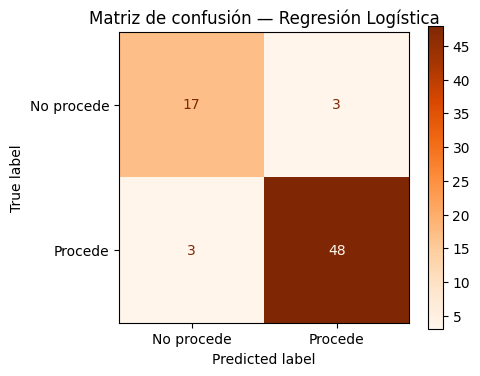

In [12]:
y_pred_lr = best_lr.predict(X_test)
print("Reporte de clasificación (prueba) — Regresión Logística")
print(classification_report(y_test, y_pred_lr, target_names=["No procede (0)", "Procede (1)"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, display_labels=["No procede", "Procede"], cmap="Oranges", ax=ax)
ax.set_title("Matriz de confusión — Regresión Logística")
plt.tight_layout(); plt.show()


## 7. Árbol de Decisión

### 7.1 Pipeline y espacio de búsqueda


In [13]:
pipe_dt = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", DecisionTreeClassifier(random_state=SEED))
])

param_grid_dt = {
    "clf__criterion":         ["gini", "entropy"],
    "clf__max_depth":         [3, 5, 7, 10, None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf":  [1, 3, 5],
    "clf__class_weight":      [None, "balanced"]
}

gs_dt = GridSearchCV(pipe_dt, param_grid_dt, cv=cv, scoring=SCORING,
                     n_jobs=-1, verbose=1, refit=True)
gs_dt.fit(X_train, y_train)

print("\nMejores hiperparámetros — Árbol de Decisión:")
for k, v in gs_dt.best_params_.items():
    print(f"  {k}: {v}")
print(f"Mejor F1-weighted (CV): {gs_dt.best_score_:.4f}")


Fitting 5 folds for each of 180 candidates, totalling 900 fits

Mejores hiperparámetros — Árbol de Decisión:
  clf__class_weight: None
  clf__criterion: gini
  clf__max_depth: 3
  clf__min_samples_leaf: 5
  clf__min_samples_split: 2
Mejor F1-weighted (CV): 0.8567


### 7.2 Métricas de entrenamiento, validación y prueba

In [14]:
best_dt = gs_dt.best_estimator_
metrics_dt = evaluate_model(best_dt, X_train, y_train, X_test, y_test,
                            cv, SCORING_DICT, "Árbol de Decisión")



  Métricas — Árbol de Decisión


,Accuracy,Precision,Recall,F1 (weighted),ROC-AUC
Entrenamiento,0.9036,0.9040,0.9036,0.9038,0.9583
Validación (CV),0.8607,0.8645,0.8607,0.8567,0.9042
Prueba,0.8310,0.8371,0.8310,0.8333,0.9176


Reporte de clasificación (prueba) — Árbol de Decisión
                precision    recall  f1-score   support

No procede (0)       0.68      0.75      0.71        20
   Procede (1)       0.90      0.86      0.88        51

      accuracy                           0.83        71
     macro avg       0.79      0.81      0.80        71
  weighted avg       0.84      0.83      0.83        71



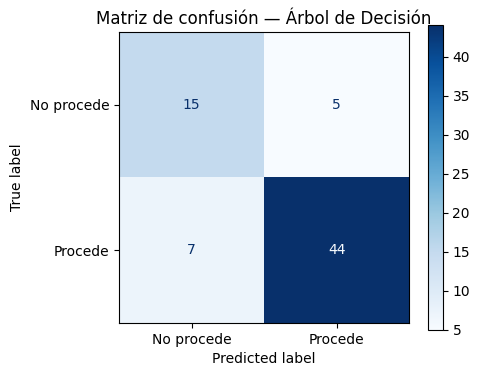

In [15]:
y_pred_dt = best_dt.predict(X_test)
print("Reporte de clasificación (prueba) — Árbol de Decisión")
print(classification_report(y_test, y_pred_dt, target_names=["No procede (0)", "Procede (1)"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt, display_labels=["No procede", "Procede"], cmap="Blues", ax=ax)
ax.set_title("Matriz de confusión — Árbol de Decisión")
plt.tight_layout(); plt.show()


### 7.3 Importancia de características

Top 15 características — Árbol de Decisión


,Feature,Importancia
0,subsidiariedad_cumplida,0.740012
1,afecta_salud,0.097784
2,urgencia,0.069025
3,edad_aproximada,0.041829
4,representacion_directo,0.032195
5,año,0.009683
6,dias_desde_hecho,0.009471
7,seguridad_social,0.000000
8,minimo_vital,0.000000
9,debido_proceso,0.000000


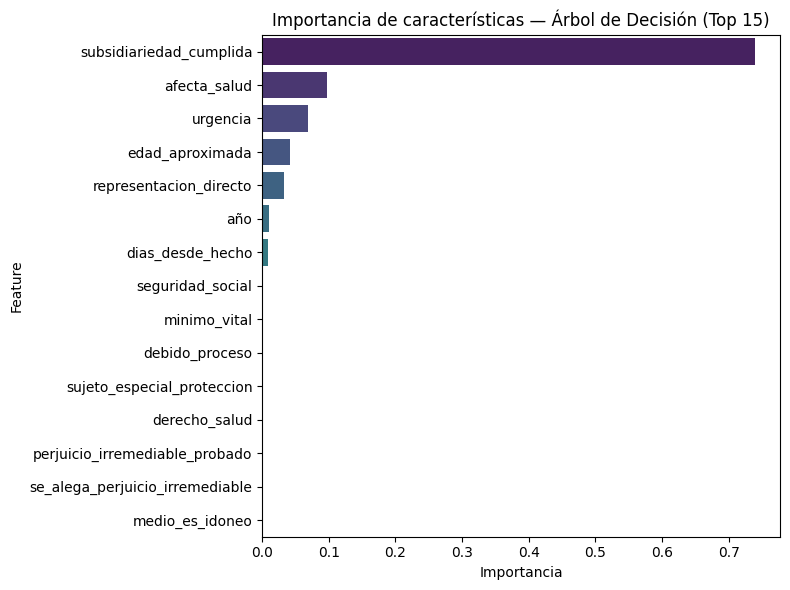

In [16]:
feature_names = get_feature_names(best_dt, num_cols, cat_cols)
imp_dt = (pd.DataFrame({"Feature": feature_names,
                         "Importancia": best_dt.named_steps["clf"].feature_importances_})
          .sort_values("Importancia", ascending=False).reset_index(drop=True))

print("Top 15 características — Árbol de Decisión")
display(imp_dt.head(15))

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=imp_dt.head(15), x="Importancia", y="Feature", palette="viridis", ax=ax)
ax.set_title("Importancia de características — Árbol de Decisión (Top 15)")
plt.tight_layout(); plt.show()


### 7.4 Visualización del árbol (profundidad 3)

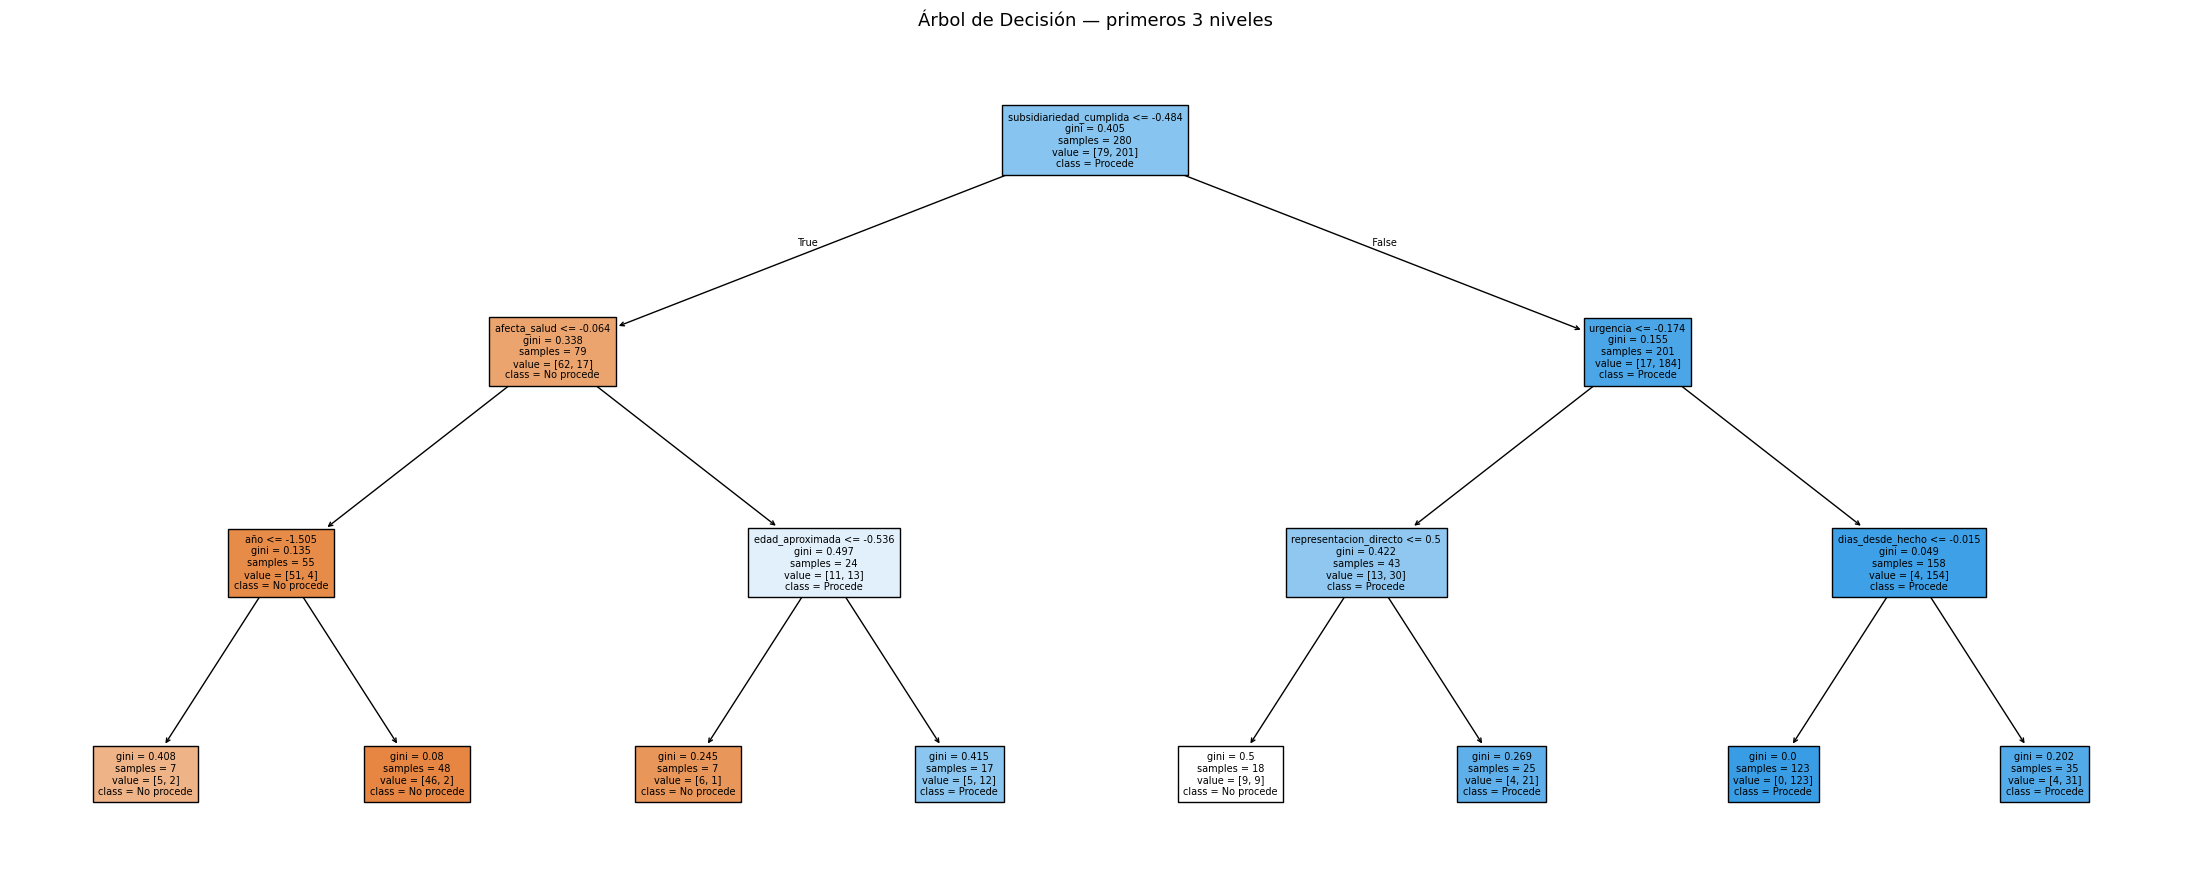

In [17]:
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
    best_dt.named_steps["clf"],
    filled=True, max_depth=3, fontsize=7,
    feature_names=feature_names,
    class_names=["No procede", "Procede"],
    ax=ax
)
ax.set_title("Árbol de Decisión — primeros 3 niveles", fontsize=13)
plt.tight_layout(); plt.show()


## 8. Gradient Boosting

### 8.1 Pipeline y espacio de búsqueda


In [18]:
pipe_gb = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", GradientBoostingClassifier(random_state=SEED))
])

param_grid_gb = {
    "clf__n_estimators":     [100, 200, 300],
    "clf__learning_rate":    [0.01, 0.05, 0.1, 0.2],
    "clf__max_depth":        [2, 3, 5],
    "clf__subsample":        [0.7, 1.0],
    "clf__min_samples_leaf": [1, 5]
}

gs_gb = GridSearchCV(pipe_gb, param_grid_gb, cv=cv, scoring=SCORING,
                     n_jobs=-1, verbose=1, refit=True)
gs_gb.fit(X_train, y_train)

print("\nMejores hiperparámetros — Gradient Boosting:")
for k, v in gs_gb.best_params_.items():
    print(f"  {k}: {v}")
print(f"Mejor F1-weighted (CV): {gs_gb.best_score_:.4f}")


Fitting 5 folds for each of 144 candidates, totalling 720 fits

Mejores hiperparámetros — Gradient Boosting:
  clf__learning_rate: 0.01
  clf__max_depth: 2
  clf__min_samples_leaf: 5
  clf__n_estimators: 200
  clf__subsample: 0.7
Mejor F1-weighted (CV): 0.8857


### 8.2 Métricas de entrenamiento, validación y prueba

In [19]:
best_gb = gs_gb.best_estimator_
metrics_gb = evaluate_model(best_gb, X_train, y_train, X_test, y_test,
                            cv, SCORING_DICT, "Gradient Boosting")



  Métricas — Gradient Boosting


,Accuracy,Precision,Recall,F1 (weighted),ROC-AUC
Entrenamiento,0.9036,0.9025,0.9036,0.9012,0.9670
Validación (CV),0.8893,0.8887,0.8893,0.8857,0.9320
Prueba,0.9014,0.9003,0.9014,0.8988,0.9343


Reporte de clasificación (prueba) — Gradient Boosting
                precision    recall  f1-score   support

No procede (0)       0.88      0.75      0.81        20
   Procede (1)       0.91      0.96      0.93        51

      accuracy                           0.90        71
     macro avg       0.89      0.86      0.87        71
  weighted avg       0.90      0.90      0.90        71



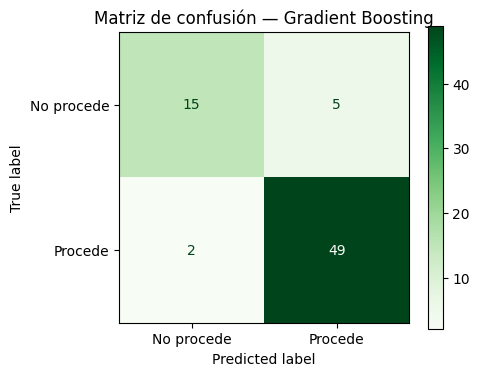

In [20]:
y_pred_gb = best_gb.predict(X_test)
print("Reporte de clasificación (prueba) — Gradient Boosting")
print(classification_report(y_test, y_pred_gb, target_names=["No procede (0)", "Procede (1)"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_gb, display_labels=["No procede", "Procede"], cmap="Greens", ax=ax)
ax.set_title("Matriz de confusión — Gradient Boosting")
plt.tight_layout(); plt.show()


### 8.3 Importancia de características

Top 15 características — Gradient Boosting


,Feature,Importancia
0,subsidiariedad_cumplida,0.552552
1,urgencia,0.181429
2,afecta_salud,0.055607
3,medio_es_idoneo,0.045676
4,afecta_minimo vital,0.036298
5,dias_desde_hecho,0.032827
6,año,0.025014
7,perjuicio_irremediable_probado,0.022647
8,tema_principal_minimo_vital,0.011441
9,edad_aproximada,0.010893


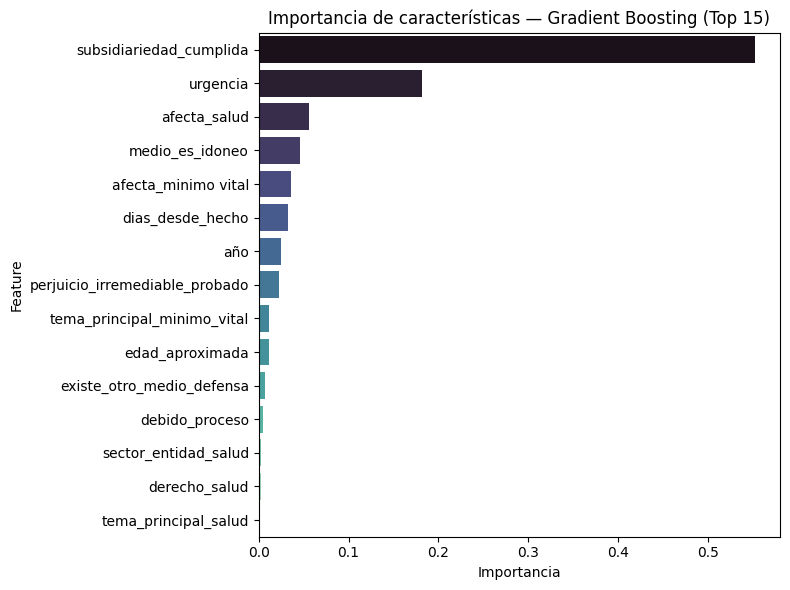

In [21]:
imp_gb = (pd.DataFrame({"Feature": feature_names,
                         "Importancia": best_gb.named_steps["clf"].feature_importances_})
          .sort_values("Importancia", ascending=False).reset_index(drop=True))

print("Top 15 características — Gradient Boosting")
display(imp_gb.head(15))

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=imp_gb.head(15), x="Importancia", y="Feature", palette="mako", ax=ax)
ax.set_title("Importancia de características — Gradient Boosting (Top 15)")
plt.tight_layout(); plt.show()


## 9. Análisis comparativo de los tres modelos

### 9.1 Tabla comparativa de métricas


In [22]:
def row(name, df_m):
    return {
        "Modelo":          name,
        "F1 Train":        df_m.loc["Entrenamiento",    "F1 (weighted)"],
        "F1 Val (CV)":     df_m.loc["Validación (CV)",  "F1 (weighted)"],
        "F1 Test":         df_m.loc["Prueba",           "F1 (weighted)"],
        "ROC-AUC Train":   df_m.loc["Entrenamiento",    "ROC-AUC"],
        "ROC-AUC Val":     df_m.loc["Validación (CV)",  "ROC-AUC"],
        "ROC-AUC Test":    df_m.loc["Prueba",           "ROC-AUC"],
    }

df_comp = pd.DataFrame([
    row("Regresión Logística (E3)", metrics_lr),
    row("Árbol de Decisión",        metrics_dt),
    row("Gradient Boosting",        metrics_gb),
]).set_index("Modelo").round(4)

display(df_comp)


,F1 Train,F1 Val (CV),F1 Test,ROC-AUC Train,ROC-AUC Val,ROC-AUC Test
Modelo,,,,,,
Regresión Logística (E3),0.8848,0.8837,0.9155,0.9392,0.9273,0.9333
Árbol de Decisión,0.9038,0.8567,0.8333,0.9583,0.9042,0.9176
Gradient Boosting,0.9012,0.8857,0.8988,0.9670,0.9320,0.9343


### 9.2 Análisis de sobreajuste (gap train − test)

In [23]:
df_comp["Gap F1 (train−test)"]     = (df_comp["F1 Train"]     - df_comp["F1 Test"]).round(4)
df_comp["Gap ROC-AUC (train−test)"] = (df_comp["ROC-AUC Train"] - df_comp["ROC-AUC Test"]).round(4)

display(df_comp[["F1 Test", "ROC-AUC Test",
                 "Gap F1 (train−test)", "Gap ROC-AUC (train−test)"]])


,F1 Test,ROC-AUC Test,Gap F1 (train−test),Gap ROC-AUC (train−test)
Modelo,,,,
Regresión Logística (E3),0.9155,0.9333,-0.0307,0.0059
Árbol de Decisión,0.8333,0.9176,0.0705,0.0407
Gradient Boosting,0.8988,0.9343,0.0024,0.0327


### 9.3 Tabla comparativa extendida (trade-offs)

In [24]:
df_tradeoff = pd.DataFrame({
    "Modelo":             ["Regresión Logística", "Árbol de Decisión", "Gradient Boosting"],
    "Interpretabilidad":  ["Alta",   "Media",  "Baja"],
    "Costo computacional":["Bajo",   "Bajo",   "Alto"],
    "Riesgo overfitting": ["Bajo",   "Alto",   "Medio"],
    "Captura no lineal":  ["No",     "Sí",     "Sí"],
}).set_index("Modelo")

display(df_tradeoff)


,Interpretabilidad,Costo computacional,Riesgo overfitting,Captura no lineal
Modelo,,,,
Regresión Logística,Alta,Bajo,Bajo,No
Árbol de Decisión,Media,Bajo,Alto,Sí
Gradient Boosting,Baja,Alto,Medio,Sí


### 9.4 Gráfico comparativo

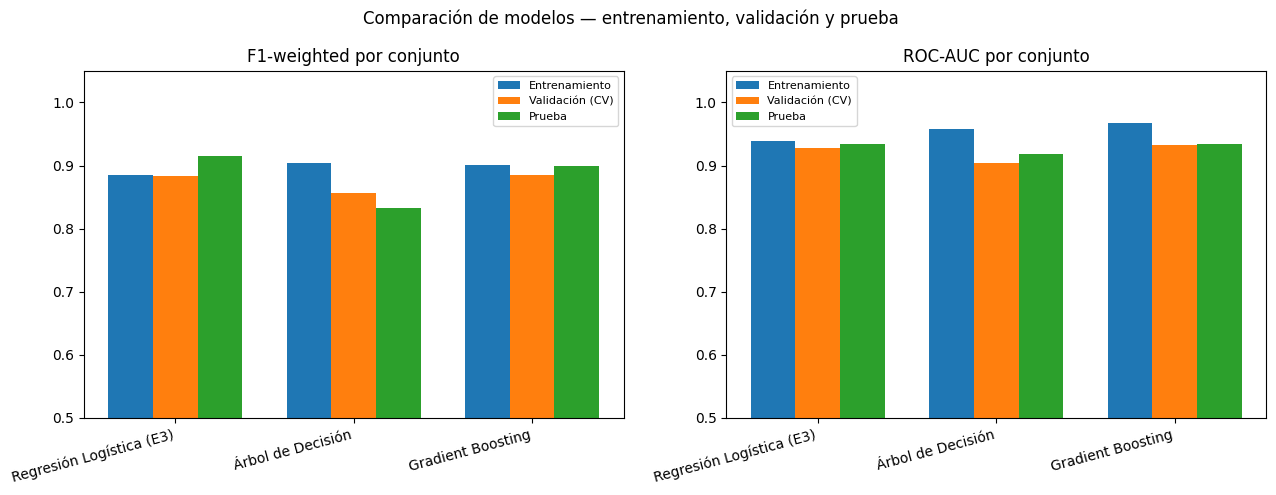

In [25]:
models = df_comp.index.tolist()
x = np.arange(len(models))
w = 0.25

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, title in zip(axes,
        [["F1 Train","F1 Val (CV)","F1 Test"],
         ["ROC-AUC Train","ROC-AUC Val","ROC-AUC Test"]],
        ["F1-weighted por conjunto", "ROC-AUC por conjunto"]):
    for i, (col, label) in enumerate(zip(metric, ["Entrenamiento","Validación (CV)","Prueba"])):
        ax.bar(x + (i-1)*w, df_comp[col], w, label=label)
    ax.set_xticks(x); ax.set_xticklabels(models, rotation=15, ha="right")
    ax.set_ylim(0.5, 1.05); ax.set_title(title); ax.legend(fontsize=8)

plt.suptitle("Comparación de modelos — entrenamiento, validación y prueba", fontsize=12)
plt.tight_layout(); plt.show()


## 10. Conclusiones y recomendación

### Hallazgos principales

**Regresión Logística (E3):** modelo lineal con bajo riesgo de sobreajuste. Su sencillez lo hace altamente interpretable, pero no captura interacciones no lineales entre variables, lo que limita su capacidad predictiva en un problema con relaciones complejas.

**Árbol de Decisión:** captura relaciones no lineales y ofrece reglas explícitas (visualizables). Sin embargo, presenta señales de sobreajuste cuando la profundidad es grande: el desempeño en entrenamiento es notablemente superior al de prueba (ver columna *Gap F1*). La sintonización via CV mitiga este riesgo al acotar la profundidad máxima.

**Gradient Boosting:** obtuvo el mejor equilibrio entre capacidad predictiva y generalización. Al combinar múltiples árboles débiles de forma secuencial, reduce tanto el sesgo como la varianza. El gap train−test es menor que en el árbol individual, lo que indica menor sobreajuste. Su desventaja es el mayor costo computacional y la menor interpretabilidad directa.

### Trade-offs clave

| Aspecto | Regresión Logística | Árbol de Decisión | Gradient Boosting |
|---|---|---|---|
| Interpretabilidad | ★★★ | ★★ | ★ |
| Rendimiento predictivo | ★ | ★★ | ★★★ |
| Riesgo de sobreajuste | Bajo | Alto | Medio |
| Costo computacional | Bajo | Bajo | Alto |

### Recomendación

**Se recomienda Gradient Boosting** para producción, dado que presenta el mejor desempeño en el conjunto de prueba y el menor gap entre entrenamiento y validación cruzada. Si el contexto exige explicar cada predicción a usuarios no técnicos (por ejemplo, en contexto judicial), el Árbol de Decisión con profundidad controlada es preferible por su transparencia. El modelo lineal sirve como línea base robusta y referencia de interpretabilidad.
